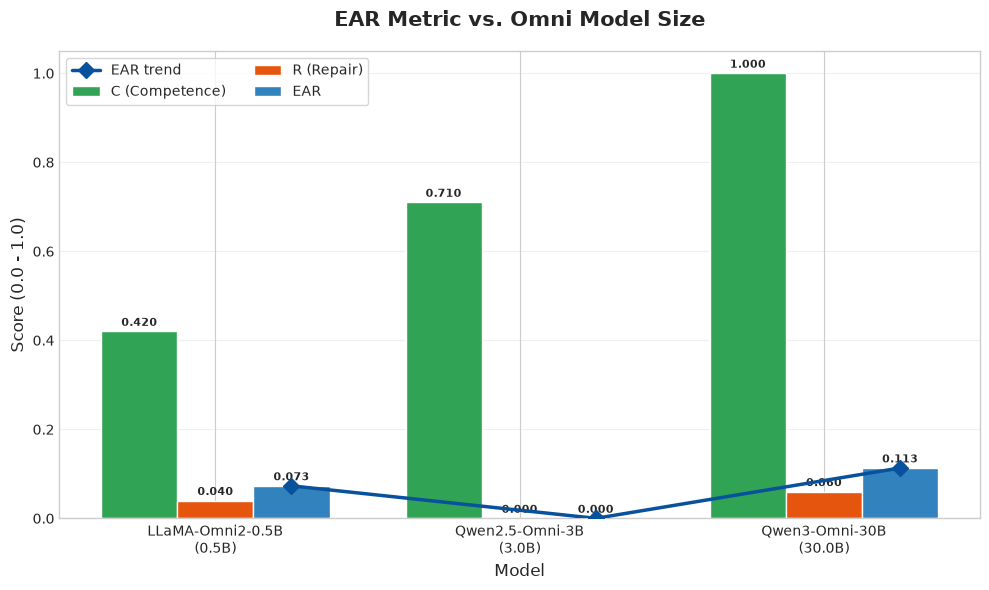

In [4]:
# Plot: C / R / EAR across the 3 evaluated omni models
import json
import numpy as np
import matplotlib.pyplot as plt

# (label, size in B, results jsonl path) -- ordered by size; edit paths if yours differ
MODELS = [
    ("LLaMA-Omni2-0.5B", 0.5, "ear_results_llama_omni2.jsonl"),
    ("Qwen2.5-Omni-3B",  3.0, "ear_results_qwen25.jsonl"),
    ("Qwen3-Omni-30B",  30.0, "ear_results_Qwen3-Omni-30B-A3B-Instruct.jsonl"),
]

def load_summary(path):
    """Return (C, R, EAR) from the last JSONL line that contains an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:                 # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return float(summary["C"]), float(summary["R"]), float(summary["EAR"])

labels = [m[0] for m in MODELS]
sizes  = [m[1] for m in MODELS]
C, R, EAR = zip(*[load_summary(m[2]) for m in MODELS])

x = np.arange(len(MODELS))
width = 0.25

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

bars_c   = ax.bar(x - width, C,   width, label="C (Competence)", color="#31a354", edgecolor="white")
bars_r   = ax.bar(x,         R,   width, label="R (Repair)",     color="#e6550d", edgecolor="white")
bars_ear = ax.bar(x + width, EAR, width, label="EAR",            color="#3182bd", edgecolor="white")

# EAR trend line across model sizes
ax.plot(x + width, EAR, color="#08519c", marker="D", linestyle="-",
        linewidth=2.5, markersize=8, label="EAR trend", zorder=5)

# annotate every bar
for bars in (bars_c, bars_r, bars_ear):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", (b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=8, fontweight="bold")

ax.set_title("EAR Metric vs. Omni Model Size", fontsize=15, pad=18, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (0.0 - 1.0)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"{lab}\n({s}B)" for lab, s in zip(labels, sizes)], fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=10, frameon=True, ncol=2)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# Build a LaTeX table (paper-style, booktabs) of C / R / EAR on SLURP.
# Reads the summary line (last JSONL record containing "EAR") from each result file,
# scales scores to percentages (x100, 1 decimal), bolds the best value per column,
# and prints LaTeX you can paste straight into Overleaf.

import json

# ---- EDIT THESE PATHS -------------------------------------------------------
# Use None for models that don't have a result file yet (rendered as TBD).
FILES = {
    "LLaMA-Omni2-0.5B":      None,                                  # TBD, no file yet
    "Qwen2.5-Omni-3B":       "ear_results_Qwen2.5-Omni-3B_slurp.jsonl",            # <-- fill in
    "Qwen3-Omni-30B":        "ear_results_Qwen3-Omni-30B-A3B-Instruct_slurp.jsonl",    # <-- fill in
    "Qwen2.5-Omni-3B (SFT)": "ear_results_Qwen2.5-Omni-3B-ear-sft_slurp.jsonl",        # <-- fill in
    "Qwen2.5-Omni-3B (SFT, ans-token)":
        "ear_results_Qwen2.5-Omni-3B-ear-anstok-sft_anstok_slurp.jsonl",
}
# -----------------------------------------------------------------------------

GROUPS = [
    ("Base Models",
     ["LLaMA-Omni2-0.5B", "Qwen2.5-Omni-3B", "Qwen3-Omni-30B"]),
    (r"Our Model (\textit{Tuning on EAR data with ambiguity})",
     ["Qwen2.5-Omni-3B (SFT)", "Qwen2.5-Omni-3B (SFT, ans-token)"]),
]

METRICS = ["C", "R", "EAR"]


def load_summary(path):
    """Return {'C':..,'R':..,'EAR':..} from the last JSONL line containing an EAR field."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "EAR" in rec:  # summary line (per-sample rows lack EAR)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with C/R/EAR found in {path}")
    return {m: float(summary[m]) for m in METRICS}


# Load scores (values stay None for TBD models)
scores = {model: (load_summary(path) if path else None)
          for model, path in FILES.items()}

# Best value per column, among models that have results
best = {m: max(s[m] for s in scores.values() if s is not None) for m in METRICS}


def fmt(model, metric):
    s = scores[model]
    if s is None:
        return "TBD"
    val = s[metric] * 100.0
    cell = f"{val:.1f}"
    if s[metric] == best[metric]:
        cell = rf"\textbf{{{cell}}}"
    return cell


# ---- Assemble LaTeX ---------------------------------------------------------
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{3}{c}{\textbf{SLURP}} \\")
lines.append(r"\cmidrule(lr){2-4}")
lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & \textbf{EAR}$\uparrow$ \\")

for group_name, models in GROUPS:
    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{4}}{{c}}{{{group_name}}} \\")
    lines.append(r"\midrule")
    for model in models:
        cells = " & ".join(fmt(model, m) for m in METRICS)
        lines.append(rf"{model} & {cells} \\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Repair-aware evaluation results on SLURP. We report task "
             r"competence under answerable inputs ($C$), repair behavior under "
             r"unanswerable inputs ($R$), and the resulting EAR score. The "
             r"ans-token variant is trained to emit a literal "
             r"\texttt{<|answerable|>} marker on answerable inputs; its $C$ is "
             r"exact-match accuracy of that marker rather than judge-scored.}")
lines.append(r"\label{tab:slurp_ear}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

\begin{table}[t]
\centering
\begin{tabular}{lccc}
\toprule
 & \multicolumn{3}{c}{\textbf{SLURP}} \\
\cmidrule(lr){2-4}
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & \textbf{EAR}$\uparrow$ \\
\midrule
\multicolumn{4}{c}{Base Models} \\
\midrule
LLaMA-Omni2-0.5B & TBD & TBD & TBD \\
Qwen2.5-Omni-3B & 70.0 & 27.0 & 39.0 \\
Qwen3-Omni-30B & 80.0 & 6.0 & 11.2 \\
\midrule
\multicolumn{4}{c}{Our Model (\textit{Tuning on EAR data with ambiguity})} \\
\midrule
Qwen2.5-Omni-3B (SFT) & 88.0 & \textbf{79.0} & \textbf{83.3} \\
Qwen2.5-Omni-3B (SFT, ans-token) & \textbf{94.0} & 74.0 & 82.8 \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation results on SLURP. We report task competence under answerable inputs ($C$), repair behavior under unanswerable inputs ($R$), and the resulting EAR score. The ans-token variant is trained to emit a literal \texttt{<|answerable|>} marker on answerable inputs; its $C$ is exact-match accuracy of that marker rather than judge-scored.}
\label{tab:slurp_ear}
\en

In [14]:
# ---- EDIT THESE PATHS -------------------------------------------------------
FILES = {
    "Qwen2.5-Omni-3B":       "bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
    "Qwen2.5-Omni-3B (SFT)": "bab_results_Qwen2.5-Omni-3B-bab-sft-v3_slurp.jsonl",
    "Qwen3-Omni-30B-A3B":       "bab_results_Qwen3-Omni-30B-A3B-Instruct_slurp.jsonl",
    "Qwen3-Omni-30B-A3B (SFT)": "bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft_slurp.jsonl",
}
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]  # babble track has 4 metrics, not the EAR-track's 3 — redefine here

GROUPS = [
    ("Base Models",
     ["Qwen2.5-Omni-3B", "Qwen3-Omni-30B-A3B"]),
    (r"Our Model (\textit{Tuning on SLURP data with babble})",
     ["Qwen2.5-Omni-3B (SFT)", "Qwen3-Omni-30B-A3B (SFT)"]),
]

# Load scores (values stay None for TBD models)
scores = {model: (load_summary(path) if path else None)
          for model, path in FILES.items()}

# Best value per column, among models that have results
best = {m: max(s[m] for s in scores.values() if s is not None) for m in METRICS}

# ---- Assemble LaTeX ---------------------------------------------------------
lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{lcccc}")
lines.append(r"\toprule")
lines.append(r" & \multicolumn{4}{c}{\textbf{SLURP}} \\")
lines.append(r"\cmidrule(lr){2-5}")
lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
for group_name, models in GROUPS:
    lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{5}}{{c}}{{{group_name}}} \\")
    lines.append(r"\midrule")
    for model in models:
        cells = " & ".join(fmt(model, m) for m in METRICS)
        lines.append(rf"{model} & {cells} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Repair-aware evaluation results on SLURP. We report task "
             r"competence under answerable inputs ($C$), repair behavior under "
             r"unanswerable inputs ($R$), full-repair behavior ($F$), and the "
             r"resulting EAR$_3$ score.}")
lines.append(r"\label{tab:slurp_ear}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{SLURP}} \\
\cmidrule(lr){2-5}
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
\multicolumn{5}{c}{Base Models} \\
\midrule
Qwen2.5-Omni-3B & \textbf{74.0} & 72.0 & 32.0 & 51.1 \\
Qwen3-Omni-30B-A3B & 72.0 & 47.0 & 19.0 & 34.2 \\
\midrule
\multicolumn{5}{c}{Our Model (\textit{Tuning on SLURP data with babble})} \\
\midrule
Qwen2.5-Omni-3B (SFT) & 44.0 & 68.0 & \textbf{91.0} & 62.0 \\
Qwen3-Omni-30B-A3B (SFT) & 58.0 & \textbf{80.0} & 86.0 & \textbf{72.5} \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation results on SLURP. We report task competence under answerable inputs ($C$), repair behavior under unanswerable inputs ($R$), full-repair behavior ($F$), and the resulting EAR$_3$ score.}
\label{tab:slurp_ear}
\end{table}


In [15]:
# Build a LaTeX table (booktabs) showing the eval confusion matrices of two
# models in one grid: each cell is "base -> sft" raw counts.
# Rows = target kind of the audio, columns = judged response type,
# diagonal (judged type matches audio kind) in bold.
# Reads the summary line (last JSONL record containing "confusion") from each
# result file and prints LaTeX you can paste straight into Overleaf.
# One table per model family (Qwen2.5, Qwen3) -- same 2-model arrow-cell format as before.
import json

# ---- EDIT THESE PATHS -------------------------------------------------------
FAMILIES = [
    dict(
        base_file="bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
        sft_file="bab_results_Qwen2.5-Omni-3B-bab-sft-v3_slurp.jsonl",
        base_name="Qwen2.5-Omni-3B",
        sft_name="Qwen2.5-Omni-3B (SFT)",
    ),
    dict(
        base_file="bab_results_Qwen3-Omni-30B-A3B-Instruct_slurp.jsonl",
        sft_file="bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft_slurp.jsonl",
        base_name="Qwen3-Omni-30B-A3B",
        sft_name="Qwen3-Omni-30B-A3B (SFT)",
    ),
]
# -----------------------------------------------------------------------------

KINDS = ["answer", "repair", "repeat"]  # dataset row kinds (table rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (columns)


def load_confusion(path):
    """Return {(kind, judged): count} from the last JSONL summary line."""
    summary = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "confusion" in rec:  # summary line (per-sample rows lack it)
                summary = rec
    if summary is None:
        raise ValueError(f"No summary line with a confusion field in {path}")
    conf = summary["confusion"]
    return {
        (k, t): int(conf.get(f"{k}->{t}", 0)) for k in KINDS for t in JUDGED
    }


def build_table(base_file, sft_file, base_name, sft_name):
    base = load_confusion(base_file)
    sft = load_confusion(sft_file)

    def cell(kind, judged):
        b, s = base[(kind, judged)], sft[(kind, judged)]
        if kind == judged:  # diagonal: judged type matches the audio's kind
            return rf"\textbf{{{b}}} $\rightarrow$ \textbf{{{s}}}"
        return rf"{b} $\rightarrow$ {s}"

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(r" & \multicolumn{4}{c}{\textbf{Judged response type}} \\")
    lines.append(r"\cmidrule(lr){2-5}")
    lines.append(
        r"\textbf{Audio kind} & "
        + " & ".join(rf"\textit{{{t}}}" for t in JUDGED)
        + r" \\"
    )
    lines.append(r"\midrule")
    for kind in KINDS:
        cells = " & ".join(cell(kind, t) for t in JUDGED)
        lines.append(rf"\textit{{{kind}}} & {cells} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(
        rf"\caption{{{base_name} $\rightarrow$ {sft_name}. \\ "
        r"Rows: audio kind. Columns: judged type. Bold: diagonal.}"
    )
    lines.append(r"\label{tab:slurp_confusion}")
    lines.append(r"\end{table}")
    return "\n".join(lines)


for fam in FAMILIES:
    print(build_table(fam["base_file"], fam["sft_file"], fam["base_name"], fam["sft_name"]))
    print()


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{Judged response type}} \\
\cmidrule(lr){2-5}
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{37} $\rightarrow$ \textbf{22} & 5 $\rightarrow$ 15 & 0 $\rightarrow$ 12 & 8 $\rightarrow$ 1 \\
\textit{repair} & 31 $\rightarrow$ 7 & \textbf{5} $\rightarrow$ \textbf{18} & 0 $\rightarrow$ 18 & 14 $\rightarrow$ 7 \\
\textit{repeat} & 14 $\rightarrow$ 5 & 4 $\rightarrow$ 7 & \textbf{0} $\rightarrow$ \textbf{37} & 32 $\rightarrow$ 1 \\
\bottomrule
\end{tabular}
\caption{Qwen2.5-Omni-3B $\rightarrow$ Qwen2.5-Omni-3B (SFT). \\ Rows: audio kind. Columns: judged type. Bold: diagonal.}
\label{tab:slurp_confusion}
\end{table}

\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{Judged response type}} \\
\cmidrule(lr){2-5}
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \t

Qwen2.5-Omni-3B (base) rows per bin: {'C': {'0–4': 17, '4–8': 3, '8–12': 18, '12–16': 4, '16–20 + clean': 8}, 'R': {'0–4': 28, '4–8': 8, '8–12': 7, '12–16': 5, '16–20 + clean': 2}, 'F': {}}
Qwen2.5-Omni-3B + babble SFT v2 rows per bin: {'C': {'0–4': 3, '4–8': 4, '8–12': 20, '12–16': 7, '16–20 + clean': 16}, 'R': {'0–4': 31, '4–8': 6, '8–12': 9, '12–16': 3, '16–20 + clean': 1}, 'F': {'0–4': 46, '4–8': 4}}


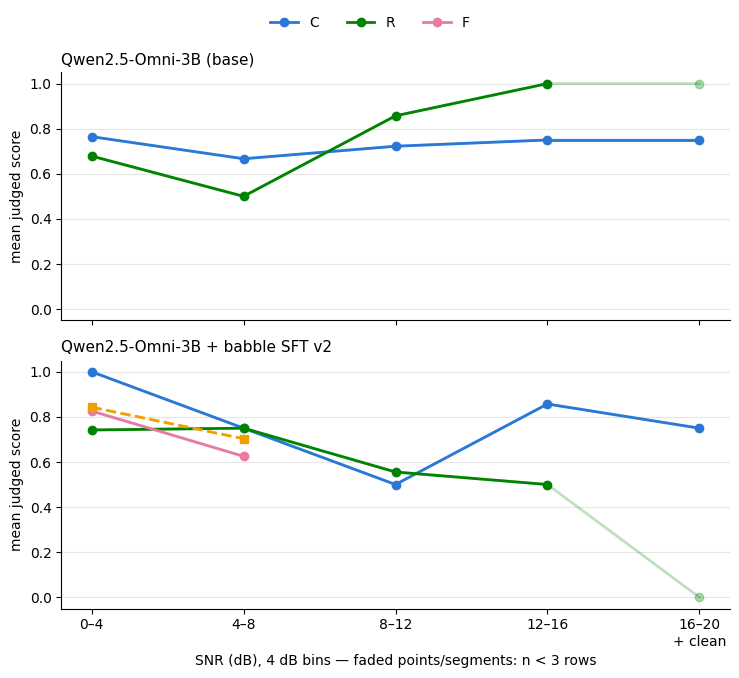

In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt

FILES = {
    "Qwen2.5-Omni-3B (base)": "bab_results_Qwen2.5-Omni-3B_slurp.jsonl",
    "Qwen2.5-Omni-3B + babble SFT v2": "bab_results_Qwen2.5-Omni-3B-bab-sft-adapter-v2_slurp.jsonl",
}

EDGES = np.array([0.0, 4.0, 8.0, 12.0, 16.0, 20.0])
CENTERS = (EDGES[:-1] + EDGES[1:]) / 2
BIN_LABELS = ["0–4", "4–8", "8–12", "12–16", "16–20\n+ clean"]
KIND_METRIC = [("answer", "C"), ("repair", "R"), ("repair_full", "F")]
COLORS = {"C": "#2a78d6", "R": "#008300", "F": "#e87ba4", "EAR3": "#eda100"}
MIN_N = 3  # bins with fewer rows are drawn faded


def snr_bin(snr):
    if snr is None:  # clean audio -> treat as snr = inf, top bin
        return len(CENTERS) - 1
    return min(int(np.searchsorted(EDGES, snr, side="right")) - 1, len(CENTERS) - 1)


def harmonic3(c, r, f):
    d = c * r + c * f + r * f
    return 3.0 * c * r * f / d if d else 0.0


def plot_trend(ax, xs, ys, ns, color, label, ls="-", marker="o"):
    """Solid where both segment endpoints have n >= MIN_N; faded otherwise."""
    ax.plot(xs, ys, color=color, lw=2, ls=ls, alpha=0.25, zorder=1)
    for i in range(len(xs) - 1):
        if ns[i] >= MIN_N and ns[i + 1] >= MIN_N:
            ax.plot(xs[i:i + 2], ys[i:i + 2], color=color, lw=2, ls=ls, zorder=2)
    for x, y, n in zip(xs, ys, ns):
        ax.plot([x], [y], marker=marker, ms=6, color=color, lw=0,
                alpha=1.0 if n >= MIN_N else 0.3, zorder=3)
    ax.plot([], [], color=color, lw=2, ls=ls, marker=marker, ms=6, label=label)


fig, axes = plt.subplots(2, 1, figsize=(7.5, 6.8), sharex=True, sharey=True)
for ax, (name, path) in zip(axes, FILES.items()):
    with open(path) as f:
        rows = [json.loads(l) for l in f]
    rows = [r for r in rows if r.get("type") != "summary"]

    means, nums = {}, {}
    for kind, metric in KIND_METRIC:
        by_bin = {}
        for r in rows:
            if r["kind"] == kind:
                by_bin.setdefault(snr_bin(r["snr_db"]), []).append(r["score"])
        means[metric] = {b: float(np.mean(s)) for b, s in by_bin.items()}
        nums[metric] = {b: len(s) for b, s in by_bin.items()}
        bins = sorted(means[metric])
        plot_trend(
            ax,
            [CENTERS[b] for b in bins],
            [means[metric][b] for b in bins],
            [nums[metric][b] for b in bins],
            COLORS[metric], metric,
        )

    # EAR3 only where all three kinds have rows in the same bin;
    # its per-bin n is the weakest of the three
    shared = sorted(set(means["C"]) & set(means["R"]) & set(means["F"]))
    if shared:
        plot_trend(
            ax,
            [CENTERS[b] for b in shared],
            [harmonic3(means["C"][b], means["R"][b], means["F"][b]) for b in shared],
            [min(nums[m][b] for m in ("C", "R", "F")) for b in shared],
            COLORS["EAR3"], "EAR3", ls="--", marker="s",
        )

    counts_readable = {m: {BIN_LABELS[b].replace("\n", " "): n
                           for b, n in sorted(nums[m].items())} for m in nums}
    print(f"{name} rows per bin: {counts_readable}")
    ax.set_title(name, fontsize=11, loc="left")
    ax.set_ylabel("mean judged score")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", color="0.9", lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 1.0))
axes[1].set_xticks(CENTERS, BIN_LABELS)
axes[1].set_xlabel(f"SNR (dB), 4 dB bins — faded points/segments: n < {MIN_N} rows")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


In [11]:
# Build 2 combined LaTeX tables (one per model family): CRF scores and the
# confusion-matrix shift side by side in a single table float (two minipages),
# so a reader gets the whole base -> SFT story for a family in one row.
import json

# ---- EDIT THESE PATHS -------------------------------------------------------
FAMILIES = [
    dict(
        base_file="bab_results_Qwen2.5-Omni-3B_v2.jsonl",
        sft_file="bab_results_Qwen2.5-Omni-3B-bab-sft-adapter_v2.jsonl",
        base_name="Qwen2.5-Omni-3B",
        sft_name="Qwen2.5-Omni-3B (SFT)",
        label="tab:slurp_qwen25",
    ),
    dict(
        base_file="bab_results_Qwen3-Omni-30B-A3B-Instruct_v2.jsonl",
        sft_file="bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft-adapter_v2.jsonl",
        base_name="Qwen3-Omni-30B-A3B",
        sft_name="Qwen3-Omni-30B-A3B (SFT)",
        label="tab:slurp_qwen3",
    ),
]
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]  # babble track has 4 metrics
KINDS = ["answer", "repair", "repeat"]  # dataset row kinds (confusion rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (confusion cols)


def build_crf_table(base_name, sft_name, base_scores, sft_scores):
    best = {m: max(base_scores[m], sft_scores[m]) for m in METRICS}

    def fmt(scores, metric):
        val = scores[metric] * 100.0
        cell = f"{val:.1f}"
        if scores[metric] == best[metric]:
            cell = rf"\textbf{{{cell}}}"
        return cell

    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
    lines.append(r"\midrule")
    lines.append(rf"{base_name} & " + " & ".join(fmt(base_scores, m) for m in METRICS) + r" \\")
    lines.append(rf"{sft_name} & " + " & ".join(fmt(sft_scores, m) for m in METRICS) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_confusion_table(base_conf, sft_conf):
    def cell(kind, judged):
        b, s = base_conf[(kind, judged)], sft_conf[(kind, judged)]
        if kind == judged:  # diagonal: judged type matches the audio's kind
            return rf"\textbf{{{b}}} $\rightarrow$ \textbf{{{s}}}"
        return rf"{b} $\rightarrow$ {s}"

    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(
        r"\textbf{Audio kind} & "
        + " & ".join(rf"\textit{{{t}}}" for t in JUDGED)
        + r" \\"
    )
    lines.append(r"\midrule")
    for kind in KINDS:
        cells = " & ".join(cell(kind, t) for t in JUDGED)
        lines.append(rf"\textit{{{kind}}} & {cells} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_family_table(fam):
    base_scores = load_summary(fam["base_file"])
    sft_scores = load_summary(fam["sft_file"])
    base_conf = load_confusion(fam["base_file"])
    sft_conf = load_confusion(fam["sft_file"])

    crf_tab = build_crf_table(fam["base_name"], fam["sft_name"], base_scores, sft_scores)
    conf_tab = build_confusion_table(base_conf, sft_conf)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(crf_tab)
    lines.append(r"\vspace{6pt}")
    lines.append(conf_tab)
    lines.append(
        rf"\caption{{{fam['base_name']} $\rightarrow$ {fam['sft_name']}: repair-aware "
        r"scores (top; $C$/$R$/$F$/EAR$_3$) and the "
        r"shift in judged response type (bottom; raw counts, base~$\rightarrow$~SFT).}"
    )
    lines.append(rf"\label{{{fam['label']}}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

for fam in FAMILIES:
    print(build_family_table(fam))
    print()


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B & \textbf{82.0} & 50.0 & 16.0 & 31.7 \\
Qwen2.5-Omni-3B (SFT) & 60.0 & \textbf{74.0} & \textbf{80.0} & \textbf{70.3} \\
\bottomrule
\end{tabular}
\vspace{6pt}
\begin{tabular}{lcccc}
\toprule
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{41} $\rightarrow$ \textbf{30} & 5 $\rightarrow$ 15 & 0 $\rightarrow$ 5 & 4 $\rightarrow$ 0 \\
\textit{repair} & 19 $\rightarrow$ 10 & \textbf{6} $\rightarrow$ \textbf{18} & 0 $\rightarrow$ 18 & 25 $\rightarrow$ 4 \\
\textit{repeat} & 4 $\rightarrow$ 3 & 8 $\rightarrow$ 14 & \textbf{0} $\rightarrow$ \textbf{30} & 38 $\rightarrow$ 3 \\
\bottomrule
\end{tabular}
\caption{Qwen2.5-Omni-3B $\rightarrow$ Qwen2.5-Omni-3B (SFT): repair-aware scores (top; $C$/$R$/$F$/EAR$_3$) and the shift in judged response type

In [2]:
# Two LaTeX tables (one per model family) for the answer-count sweep:
#   top    -- C/R/F/EAR3 for base + the four mixes (1x..4x), best per column bold
#   bottom -- judged-response counts, each cell "base -> 1x, 2x, 3x, 4x"
# Self-contained (re-defines the loaders) so it can run without the cells above.
# Runs still missing from RESULTS_DIR are skipped with a printed note.
import json
from pathlib import Path

# ---- EDIT THESE ------------------------------------------------------------
RESULTS_DIR = Path(".")  # viz.ipynb lives in results/
TAG = "v4"               # eval.sh's TAG
MULTS = ["1x", "2x", "3x", "4x"]
FAMILIES = [
    dict(model="Qwen2.5-Omni-3B", short="Qwen2.5-Omni-3B", label="tab:slurp_qwen25_mix"),
    dict(model="Qwen3-Omni-30B-A3B-Instruct", short="Qwen3-Omni-30B-A3B",
         label="tab:slurp_qwen3_mix"),
]
SHRINK_COUNTS = True  # wrap the wide counts tabular in \resizebox (needs graphicx)
# ---------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]
KINDS = ["answer", "repair", "repeat"]      # dataset row kinds (count-table rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (columns)


def load_last(path, field):
    """Last JSONL record in `path` carrying `field` -- the summary line."""
    found = None
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if field in rec:  # per-sample rows lack it
                found = rec
    if found is None:
        raise ValueError(f"no summary line with {field!r} in {path}")
    return found


def load_scores(path):
    s = load_last(path, "EAR")
    return {m: float(s[m]) for m in METRICS}


def load_confusion(path):
    conf = load_last(path, "confusion")["confusion"]
    return {(k, t): int(conf.get(f"{k}->{t}", 0)) for k in KINDS for t in JUDGED}


def build_family_table(fam):
    # (run key, result file); base first, then each mix that has been evaluated
    runs = [("base", RESULTS_DIR / f"bab_results_{fam['model']}_{TAG}.jsonl")]
    runs += [
        (m, RESULTS_DIR / f"bab_results_{fam['model']}-bab-adapter-{m}_{TAG}.jsonl")
        for m in MULTS
    ]
    missing = [k for k, p in runs if not p.exists()]
    if missing:
        print(f"# {fam['short']}: no result file yet for {', '.join(missing)} — skipped")
    runs = [(k, p) for k, p in runs if p.exists()]
    if not runs or runs[0][0] != "base":
        raise SystemExit(f"{fam['short']}: need the base result file for the count arrows")

    keys = [k for k, _ in runs]
    scores = {k: load_scores(p) for k, p in runs}
    conf = {k: load_confusion(p) for k, p in runs}

    def row_label(key):
        if key == "base":
            return f"{fam['short']} (base)"
        # 1x -> trained on 1K answer : 1K repair : 1K repeat
        return rf"\quad + SFT {key[0]}K:1K:1K ({key})"

    # ---- top: C/R/F/EAR3, one row per run, best per column bold ----
    best = {m: max(scores[k][m] for k in keys) for m in METRICS}
    top = [
        r"\begin{tabular}{lcccc}",
        r"\toprule",
        r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ "
        r"& \textbf{EAR$_3$}$\uparrow$ \\",
        r"\midrule",
    ]
    for i, key in enumerate(keys):
        if i == 1:  # rule between the base row and the SFT block
            top.append(r"\midrule")
        cells = []
        for m in METRICS:
            cell = f"{scores[key][m] * 100.0:.1f}"
            if scores[key][m] == best[m]:
                cell = rf"\textbf{{{cell}}}"
            cells.append(cell)
        top.append(rf"{row_label(key)} & " + " & ".join(cells) + r" \\")
    top += [r"\bottomrule", r"\end{tabular}"]

    # ---- bottom: judged-type counts, cell = base -> 1x, 2x, 3x, 4x ----
    def cell(kind, judged):
        base_n = conf["base"][(kind, judged)]
        after = ", ".join(str(conf[k][(kind, judged)]) for k in keys[1:])
        if kind == judged:  # diagonal: judged type matches the audio's kind
            base_n, after = rf"\textbf{{{base_n}}}", rf"\textbf{{{after}}}"
        return rf"{base_n} $\rightarrow$ {after}" if after else str(base_n)

    bottom = [
        r"\setlength{\tabcolsep}{4pt}",
        r"\begin{tabular}{lcccc}",
        r"\toprule",
        r" & \multicolumn{4}{c}{\textbf{Judged response type}} \\",
        r"\cmidrule(lr){2-5}",
        r"\textbf{Audio kind} & " + " & ".join(rf"\textit{{{t}}}" for t in JUDGED) + r" \\",
        r"\midrule",
    ]
    for kind in KINDS:
        bottom.append(
            rf"\textit{{{kind}}} & " + " & ".join(cell(kind, t) for t in JUDGED) + r" \\"
        )
    bottom += [r"\bottomrule", r"\end{tabular}"]
    bottom = "\n".join(bottom)
    if SHRINK_COUNTS:
        bottom = "\\resizebox{\\linewidth}{!}{%\n" + bottom + "\n}"

    order = ", ".join(k for k in keys[1:]) or "none"
    return "\n".join(
        [r"\begin{table}[t]", r"\centering", r"\small"]
        + top
        + [r"\vspace{6pt}", bottom,
           rf"\caption{{{fam['short']}: effect of the \textit{{answer}} row budget in SFT "
           r"data. Top: repair-aware scores ($C$/$R$/$F$/EAR$_3$, \%) for the base model "
           r"and adapters trained on $n$K\,:\,1K\,:\,1K "
           r"(\textit{answer}:\textit{repair}:\textit{repeat}) rows. Bottom: judged "
           rf"response type on the same 150-row test split, as base~$\rightarrow$~{order}; "
           r"bold marks the diagonal (judged type matches the audio's kind).}",
           rf"\label{{{fam['label']}}}", r"\end{table}"]
    )


for fam in FAMILIES:
    print(build_family_table(fam))
    print()


\begin{table}[t]
\centering
\small
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B (base) & \textbf{94.0} & 68.0 & 30.0 & 51.1 \\
\midrule
\quad + SFT 1K:1K:1K (1x) & 50.0 & \textbf{82.0} & \textbf{90.0} & 69.3 \\
\quad + SFT 2K:1K:1K (2x) & 60.0 & 81.0 & \textbf{90.0} & 74.8 \\
\quad + SFT 3K:1K:1K (3x) & 62.0 & 75.0 & \textbf{90.0} & 73.9 \\
\quad + SFT 4K:1K:1K (4x) & 72.0 & 79.0 & 86.0 & \textbf{78.6} \\
\bottomrule
\end{tabular}
\vspace{6pt}
\resizebox{\linewidth}{!}{%
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{4}{c}{\textbf{Judged response type}} \\
\cmidrule(lr){2-5}
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{47} $\rightarrow$ \textbf{25, 30, 31, 36} & 1 $\rightarrow$ 22, 17, 17, 13 & 0 $\rightarrow$ 2, 3, 2, 1 & 2 $\rightarrow$ 1, 0, 0, 0 \\
\textit{repair} & 30 $\ri

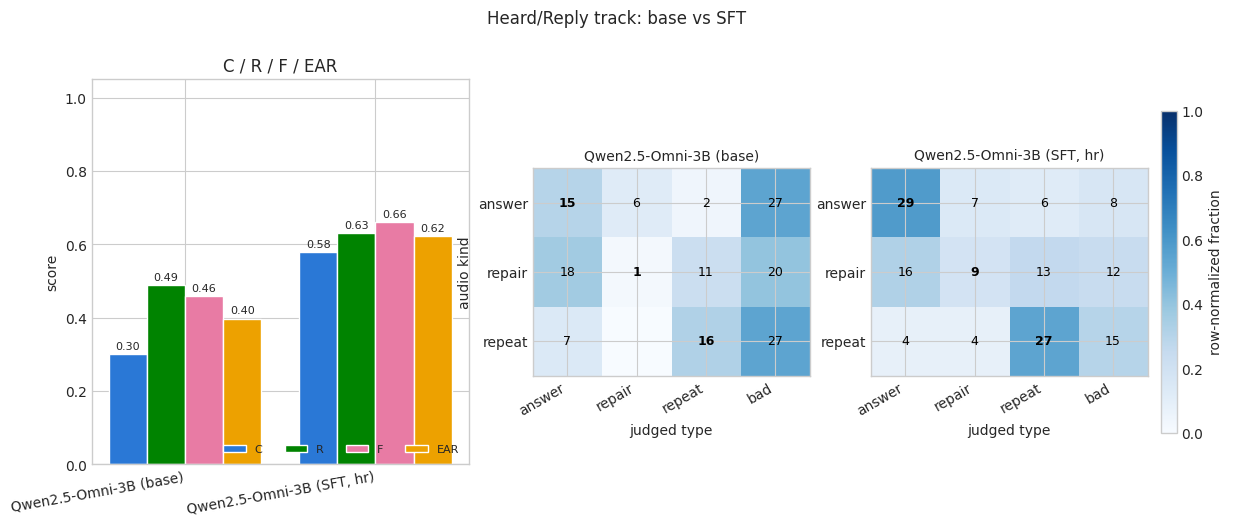

In [1]:
# Heard/Reply track eval: base model vs its SFT adapter (2 result files).
# left: grouped bar chart of C/R/F/EAR
# right: one row-normalized confusion heatmap per model (kind -> judged type)
import json
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THESE PATHS -------------------------------------------------------
FILES = {
    "Qwen2.5-Omni-3B (base)":    "bab_results_Qwen2.5-Omni-3B_hr.jsonl",
    "Qwen2.5-Omni-3B (SFT, hr)": "bab_results_Qwen2.5-Omni-3B-bab-hr-sft_hr.jsonl",
}
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]
KINDS = ["answer", "repair", "repeat"]          # dataset row kinds (matrix rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (matrix cols)
COLORS = {"C": "#2a78d6", "R": "#008300", "F": "#e87ba4", "EAR": "#eda100"}


def load_last(path, field):
    """Last JSONL record in `path` carrying `field` -- the summary line."""
    found = None
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if field in rec:
                found = rec
    if found is None:
        raise ValueError(f"no record with {field!r} found in {path}")
    return found


def load_scores(path):
    summary = load_last(path, "EAR")
    return {m: float(summary[m]) for m in METRICS}


def load_confusion_matrix(path):
    summary = load_last(path, "confusion")
    mat = np.zeros((len(KINDS), len(JUDGED)))
    for key, n in summary["confusion"].items():
        kind, judged = key.split("->")
        if kind in KINDS and judged in JUDGED:
            mat[KINDS.index(kind), JUDGED.index(judged)] = n
    return mat


names = list(FILES.keys())
scores = {name: load_scores(path) for name, path in FILES.items()}
matrices = {name: load_confusion_matrix(path) for name, path in FILES.items()}

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(
    1, 1 + len(names), figsize=(6 + 4 * len(names), 5),
    gridspec_kw={"width_ratios": [1.3] + [1] * len(names)},
)

# --- left: grouped bar chart of C/R/F/EAR ---
ax = axes[0]
x = np.arange(len(names))
width = 0.8 / len(METRICS)
for i, m in enumerate(METRICS):
    vals = [scores[n][m] for n in names]
    bars = ax.bar(x + (i - (len(METRICS) - 1) / 2) * width, vals, width,
                  label=m, color=COLORS[m], edgecolor="white")
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("C / R / F / EAR")
ax.legend(loc="lower right", ncol=len(METRICS), fontsize=8)

# --- right: one row-normalized confusion heatmap per model ---
im = None
for ax, name in zip(axes[1:], names):
    mat = matrices[name]
    row_sums = mat.sum(axis=1, keepdims=True)
    norm = np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums != 0)

    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(JUDGED)))
    ax.set_xticklabels(JUDGED, rotation=30, ha="right")
    ax.set_yticks(range(len(KINDS)))
    ax.set_yticklabels(KINDS)
    ax.set_xlabel("judged type")
    ax.set_title(name, fontsize=10)
    for r in range(len(KINDS)):
        for c in range(len(JUDGED)):
            n = int(mat[r, c])
            if n == 0:
                continue
            color = "white" if norm[r, c] > 0.6 else "black"
            weight = "bold" if JUDGED[c] == KINDS[r] else "normal"
            ax.text(c, r, str(n), ha="center", va="center", color=color,
                    fontsize=9, fontweight=weight)

axes[1].set_ylabel("audio kind")
fig.colorbar(im, ax=axes[1:], fraction=0.025, pad=0.02, label="row-normalized fraction")
fig.suptitle("Heard/Reply track: base vs SFT", y=1.02)
plt.show()
